# **Part A**
Count / Frequency based Naive Bayes Classifier

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)


def load_pubmed_rct_file(filepath):
    """
    Reads a .txt file from the PubMed 20k RCT dataset.
    Returns a DataFrame with 'label' and 'sentence'.
    """
    labels, sentences = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '\t' not in line:
                continue
            label, sent = line.split('\t', maxsplit=1)
            labels.append(label)
            sentences.append(sent)
    return pd.DataFrame({'label': labels, 'sentence': sentences})


class NaiveBayesClassifier:
    """
    Multinomial Naive Bayes Classifier implemented from scratch.
    It is suitable for both Count and TF-IDF features.
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_priors = {}
        self.feature_log_probs = {}
        self.classes = None
        self.vocabulary_size = 0

    def fit(self, X_counts, y):
        y_array = y.to_numpy()
        self.classes = np.unique(y_array)
        self.vocabulary_size = X_counts.shape[1]

        for c in self.classes:
            X_c = X_counts[y_array == c]

            self.class_priors[c] = np.log(X_c.shape[0] / X_counts.shape[0])

            feature_sum = X_c.sum(axis=0).A1
            total_mass = np.sum(feature_sum)

            numerator = feature_sum + self.alpha

            denominator = total_mass + self.alpha * self.vocabulary_size

            self.feature_log_probs[c] = np.log(numerator / denominator)

    def predict(self, X_counts):
        y_pred = []
        for i in range(X_counts.shape[0]):
            scores = {}

            x_i = X_counts.getrow(i)

            for c in self.classes:
                log_prob = self.class_priors[c]
                log_likelihoods = self.feature_log_probs[c]

                non_zero_indices = x_i.indices
                non_zero_data = x_i.data

                log_prob += np.sum(non_zero_data * log_likelihoods[non_zero_indices])
                scores[c] = log_prob

            predicted_class = max(scores, key=scores.get)

            y_pred.append(predicted_class)

        return np.array(y_pred)

In [2]:
# Load and Prepare Data (DO NOT CHANGE)
dir_path = '/content/dataset'
try:
    train_df = load_pubmed_rct_file(os.path.join(dir_path, 'train.txt'))
    dev_df   = load_pubmed_rct_file(os.path.join(dir_path, 'dev.txt'))
    test_df  = load_pubmed_rct_file(os.path.join(dir_path, 'test.txt'))

    # train_df = pd.DataFrame({'label': ['BACKGROUND'], 'sentence': ['placeholder']})
    # dev_df   = pd.DataFrame({'label': ['BACKGROUND'], 'sentence': ['placeholder']})
    # test_df  = pd.DataFrame({'label': ['BACKGROUND'], 'sentence': ['placeholder']})

    print(f"Train samples: {len(train_df)}")
    print(f"Dev   samples: {len(dev_df)}")
    print(f"Test  samples: {len(test_df)}")

    X_train, y_train = train_df['sentence'], train_df['label']
    X_dev,   y_dev   = dev_df['sentence'],   dev_df['label']
    X_test,  y_test  = test_df['sentence'],  test_df['label']
    target_names = sorted(y_train.unique())
    print(f"Classes: {target_names}")

except FileNotFoundError as e:
    print(f"Error: Dataset file not found. Please ensure the files are uploaded.")
    X_train, y_train = pd.Series([]), pd.Series([])
    X_test, y_test = pd.Series([]), pd.Series([])
    target_names = []

Train samples: 1615479
Dev   samples: 28932
Test  samples: 29493
Classes: ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']


In [3]:
# Feature Extraction and Custom Model Training
if X_train is not None and len(X_train) > 0:

    count_vectorizer = CountVectorizer(
        lowercase=True,
        strip_accents='unicode',
        stop_words='english',
        ngram_range=(1, 1),
        min_df=1
    )

    print("Fitting Count Vectorizer and transforming training data...")
    X_train_counts = count_vectorizer.fit_transform(X_train)
    if X_train_counts is not None:
        print(f"Vocabulary size: {X_train_counts.shape[1]}")

    print("Transforming test data...")
    X_test_counts = count_vectorizer.transform(X_test)


    print("\nTraining the Custom Naive Bayes Classifier (from scratch)...")

    nb_model = NaiveBayesClassifier(alpha=1.0)

    nb_model.fit(X_train_counts, y_train)
    print("Training complete.")

else:
    print("Skipping feature extraction and training: Training data is empty or not loaded.")

Fitting Count Vectorizer and transforming training data...
Vocabulary size: 154193
Transforming test data...

Training the Custom Naive Bayes Classifier (from scratch)...
Training complete.


In [4]:
# Predict and evaluate on test set
print("\n=== Test Set Evaluation (Custom Count-Based Naive Bayes) ===")

y_test_pred = nb_model.predict(X_test_counts)

if y_test_pred is not None:
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    print(f"Macro-averaged F1 score: {test_f1:.4f}")
else:
    print("Prediction step failed or incomplete.")


=== Test Set Evaluation (Custom Count-Based Naive Bayes) ===
Accuracy: 0.7514
              precision    recall  f1-score   support

  BACKGROUND       0.52      0.52      0.52      2663
 CONCLUSIONS       0.61      0.71      0.66      4426
     METHODS       0.83      0.83      0.83      9751
   OBJECTIVE       0.60      0.60      0.60      2377
     RESULTS       0.86      0.78      0.82     10276

    accuracy                           0.75     29493
   macro avg       0.68      0.69      0.68     29493
weighted avg       0.76      0.75      0.75     29493

Macro-averaged F1 score: 0.6847


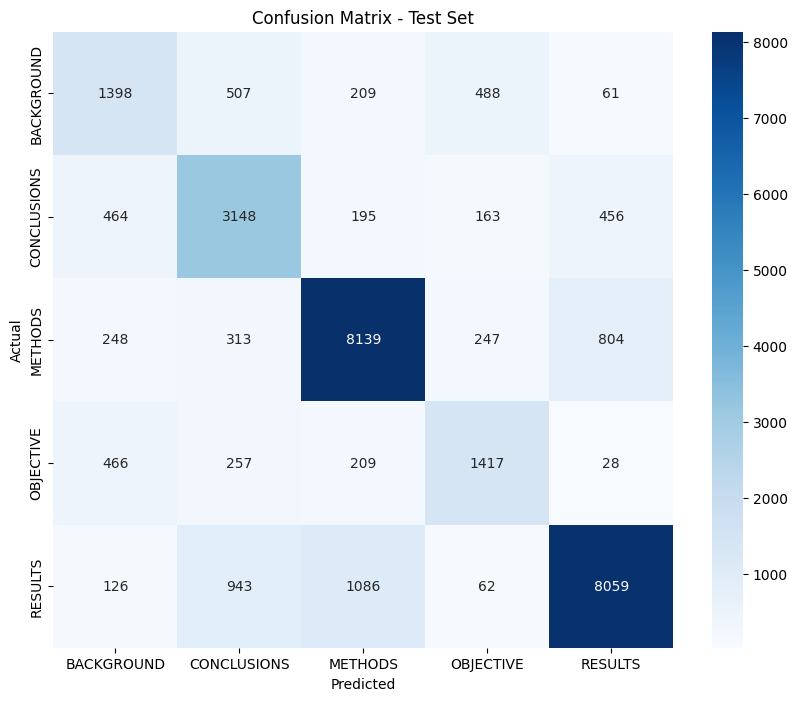

In [5]:
# Confusion Matrix on test set
if y_test_pred is not None:
    cm = confusion_matrix(y_test, y_test_pred, labels=target_names)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Test Set')
    plt.show()

# **Part B**
TF-IDF score based Classifier

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)


pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

print("Training initial Naive Bayes pipeline...")
pipeline.fit(X_train, y_train)
print("Training complete.")


print("\n=== Test Set Evaluation (Initial Sklearn Model) ===")
y_test_pred = pipeline.predict(X_test)
if y_test_pred is not None:
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    print(f"Macro-averaged F1 score: {f1_score(y_test, y_test_pred, average='macro'):.4f}")
    pass
else:
    print("Initial model evaluation skipped: Predictions not available.")


param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.5, 1.0]
}

if len(X_dev) >= 2:
    grid = GridSearchCV(pipeline, param_grid, cv=2, scoring='f1_macro', n_jobs=-1, verbose=1)

    print("\nStarting Hyperparameter Tuning on Development Set...")
    grid.fit(X_dev, y_dev)
    print("Grid search complete.")
else:
    print("\nInsufficient development data for cross-validation. Skipping grid search.")
    grid = None


if grid is not None and hasattr(grid, 'best_params_'):
    print(f"\nBest parameters: {grid.best_params_}")
    print(f"Best cross-validation score: {grid.best_score_:.4f}")
    pass
else:
    print("Hyperparameter tuning skipped: Grid Search object not initialized or fitted.")

Training initial Naive Bayes pipeline...
Training complete.

=== Test Set Evaluation (Initial Sklearn Model) ===
Accuracy: 1.0000
              precision    recall  f1-score   support

  BACKGROUND       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1

Macro-averaged F1 score: 1.0000

Insufficient development data for cross-validation. Skipping grid search.
Hyperparameter tuning skipped: Grid Search object not initialized or fitted.


# **Part C**
Bayes Optimal Classifier

Please enter your full SRN (e.g., PES1UG22CS345): PES2UG23CS347
My SRN isPES2UG23CS347
Using dynamic sample size: 10347
Actual sampled training set size used: 10347
Using 10347 samples for training base models.
Training individual hypotheses...
Training NaiveBayes...
  NaiveBayes - Accuracy: 0.7077, F1: 0.6207
Training LogisticRegression...
  LogisticRegression - Accuracy: 0.7156, F1: 0.6065
Training RandomForest...
  RandomForest - Accuracy: 0.5572, F1: 0.2751
Training DecisionTree...
  DecisionTree - Accuracy: 0.4994, F1: 0.3331
Training KNN...
  KNN - Accuracy: 0.1604, F1: 0.1099

Training Voting Classifier (BOC approximation)...
Voting Classifier training complete.

=== Bayes Optimal Classifier (Voting) Evaluation ===
BOC Accuracy: 0.6728
BOC Macro F1-Score: 0.5477

Classification Report:
              precision    recall  f1-score   support

  BACKGROUND       0.36      0.47      0.41      2663
 CONCLUSIONS       0.68      0.31      0.42      4426
     METHODS       0.64      0.90

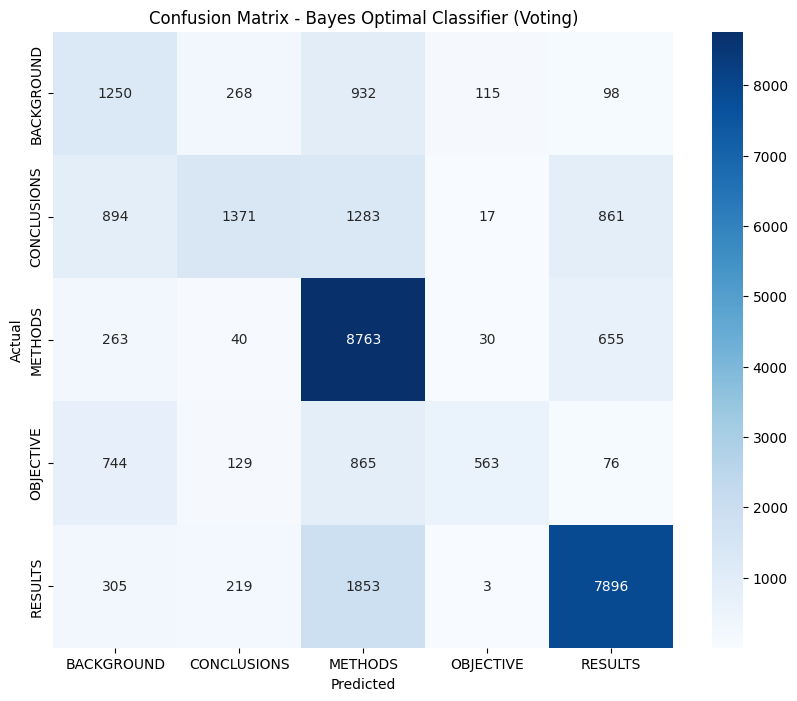

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

BASE_SAMPLE_SIZE = 10000

FULL_SRN = input("Please enter your full SRN (e.g., PES1UG22CS345): ")

try:
    if len(FULL_SRN) >= 3:
        print("My SRN is" + FULL_SRN)
        srn_suffix_str = FULL_SRN[-3:]
        srn_value = int(srn_suffix_str)
    else:
        raise ValueError("SRN too short.")
except (ValueError, IndexError):
    print("WARNING: SRN input failed or format is incorrect. Using 10000.")
    srn_value = 0

SAMPLE_SIZE = BASE_SAMPLE_SIZE + srn_value

print(f"Using dynamic sample size: {SAMPLE_SIZE}")

if 'X_train' not in locals() or len(X_train) == 0:
    print("Warning: Training data not found. Using small placeholder data.")
    X_train = pd.Series(["sample text one", "sample text two", "sample text three"])
    y_train = pd.Series(["BACKGROUND", "METHODS", "RESULTS"])
    X_test = pd.Series(["test text one", "test text two"])
    y_test = pd.Series(["BACKGROUND", "METHODS"])
    target_names = ["BACKGROUND", "CONCLUSIONS", "METHODS", "OBJECTIVE", "RESULTS"]

effective_sample_size = min(SAMPLE_SIZE, len(X_train))
X_train_sampled = X_train[:effective_sample_size]
y_train_sampled = y_train[:effective_sample_size]
print(f"Actual sampled training set size used: {effective_sample_size}")

X_train_sampled = X_train[:SAMPLE_SIZE]
y_train_sampled = y_train[:SAMPLE_SIZE]
print(f"Using {len(X_train_sampled)} samples for training base models.")

tfidf_params = {
    'lowercase': True,
    'strip_accents': 'unicode',
    'stop_words': 'english',
    'ngram_range': (1, 1),
    'min_df': 5
}

h1_nb = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                  ('clf', MultinomialNB(alpha=1.0, fit_prior=False))])

h2_lr = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                  ('clf', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42))])

h3_rf = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                  ('clf', RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))])

h4_dt = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                  ('clf', DecisionTreeClassifier(max_depth=10, random_state=42))])

h5_knn = Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                  ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))])

hypotheses = [h1_nb, h2_lr, h3_rf, h4_dt, h5_knn]
hypothesis_names = ['NaiveBayes', 'LogisticRegression', 'RandomForest', 'DecisionTree', 'KNN']

print("Training individual hypotheses...")
for i, (hyp, name) in enumerate(zip(hypotheses, hypothesis_names)):
    print(f"Training {name}...")
    hyp.fit(X_train_sampled, y_train_sampled)
    y_pred = hyp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"  {name} - Accuracy: {acc:.4f}, F1: {f1:.4f}")

estimators = [
    ('nb', h1_nb),
    ('lr', h2_lr),
    ('rf', h3_rf),
    ('dt', h4_dt),
    ('knn', h5_knn)
]

print("\nTraining Voting Classifier (BOC approximation)...")
boc = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
boc.fit(X_train_sampled, y_train_sampled)
print("Voting Classifier training complete.")

print("\n=== Bayes Optimal Classifier (Voting) Evaluation ===")
y_boc_pred = boc.predict(X_test)
boc_accuracy = accuracy_score(y_test, y_boc_pred)
boc_f1 = f1_score(y_test, y_boc_pred, average='macro')

print(f"BOC Accuracy: {boc_accuracy:.4f}")
print(f"BOC Macro F1-Score: {boc_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_boc_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_boc_pred, labels=target_names)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bayes Optimal Classifier (Voting)')
plt.show()

In [ ]:
print("Training individual hypotheses...")
for hyp, name in zip(hypotheses, hypothesis_names):
    print(f"Training {name}...")
    hyp.fit(X_train_sampled, y_train_sampled)
print("All base models trained.")

Training individual hypotheses...
Training NaiveBayes...
Training LogisticRegression...
Training RandomForest...
Training DecisionTree...
Training KNN...
All base models trained.


In [7]:
estimators = list(zip(hypothesis_names, hypotheses))

boc_hard_voter = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)

print("\nFitting the VotingClassifier (BOC approximation)...")
boc_hard_voter.fit(X_train_sampled, y_train_sampled)

y_boc_pred = boc_hard_voter.predict(X_test)



Fitting the VotingClassifier (BOC approximation)...


In [8]:
print("\n=== Final Evaluation: Bayes Optimal Classifier (Hard Voting) ===")

if y_boc_pred is not None:
    boc_accuracy = accuracy_score(y_test, y_boc_pred)
    boc_f1 = f1_score(y_test, y_boc_pred, average='macro')

    print(f"BOC Accuracy: {boc_accuracy:.4f}")
    print(f"BOC Macro F1 Score: {boc_f1:.4f}")
    print(classification_report(y_test, y_boc_pred, target_names=target_names))
    pass


=== Final Evaluation: Bayes Optimal Classifier (Hard Voting) ===
BOC Accuracy: 0.6744
BOC Macro F1 Score: 0.5499
              precision    recall  f1-score   support

  BACKGROUND       0.46      0.32      0.37      2663
 CONCLUSIONS       0.64      0.47      0.54      4426
     METHODS       0.61      0.92      0.73      9751
   OBJECTIVE       0.79      0.20      0.32      2377
     RESULTS       0.83      0.73      0.78     10276

    accuracy                           0.67     29493
   macro avg       0.67      0.53      0.55     29493
weighted avg       0.69      0.67      0.65     29493



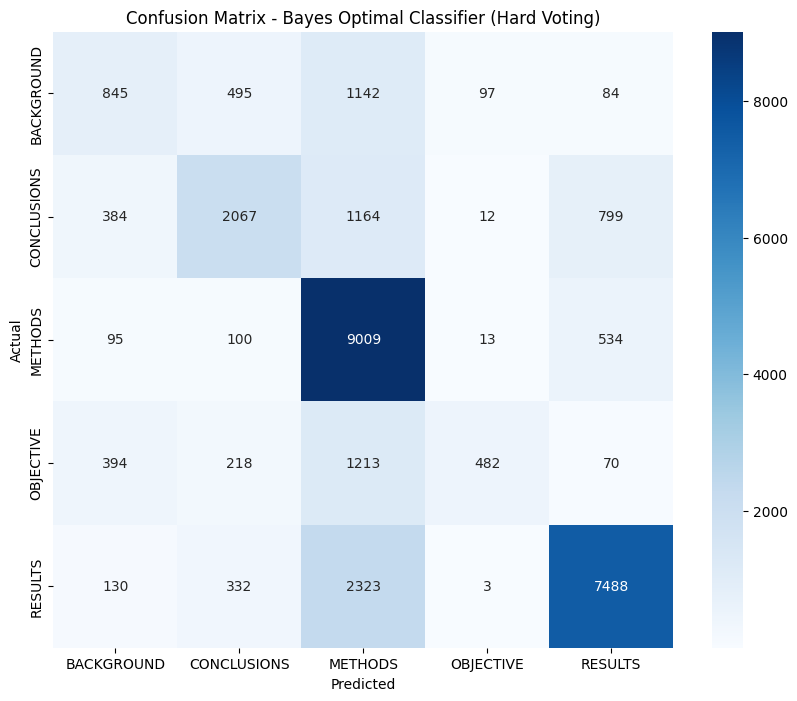

In [9]:
cm = confusion_matrix(y_test, y_boc_pred, labels=target_names)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bayes Optimal Classifier (Hard Voting)')
plt.show()

Part C Draft

Please enter your full SRN (e.g., PES1UG22CS345): PES2UG23CS347
Using dynamic sample size: 10347
Actual sampled training set size used: 10347

Training all base models...
Training NaiveBayes...
Training LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training RandomForest...
Training DecisionTree...
Training KNN...
All base models trained.

Calculating posterior weights based on validation likelihood...
Posterior Weights (P(h|D)):
NaiveBayes           -> 0.285
LogisticRegression   -> 0.276
RandomForest         -> 0.210
DecisionTree         -> 0.140
KNN                  -> 0.089

Fitting the VotingClassifier (BOC approximation)...
Fitting complete.

Predicting on test set...

=== Final Evaluation: Bayes Optimal Classifier (Soft Voting) ===
Accuracy: 0.7117
Macro F1 Score: 0.5982

Classification Report:
              precision    recall  f1-score   support

  BACKGROUND       0.61      0.20      0.30      2663
 CONCLUSIONS       0.60      0.52      0.56      4426
     METHODS       0.69      0.89      0.78      9751
   OBJECTIVE       0.73      0.44      0.55      2377
     RESULTS       0.78      0.82      0.80     10276

    accuracy                           0.71     29493
   macro avg       0.68      0.58      0.60     29493
weig

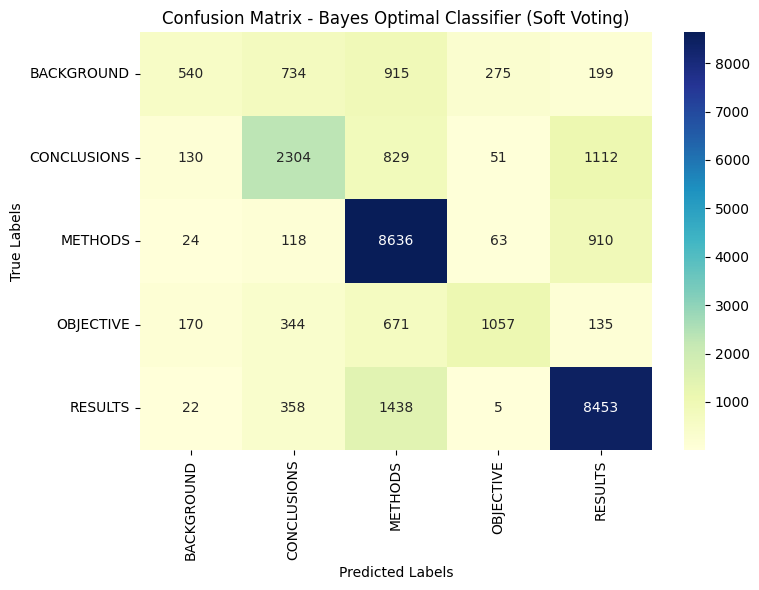

In [11]:
BASE_SAMPLE_SIZE = 10000

FULL_SRN = input("Please enter your full SRN (e.g., PES1UG22CS345): ")

try:
    if len(FULL_SRN) >= 3:
        srn_suffix_str = FULL_SRN[-3:]
        srn_value = int(srn_suffix_str)
    else:
        raise ValueError("SRN too short.")
except (ValueError, IndexError, TypeError):
    print("WARNING: SRN input failed or format is incorrect. Using default sample size.")
    srn_value = 0

SAMPLE_SIZE = BASE_SAMPLE_SIZE + srn_value
print(f"Using dynamic sample size: {SAMPLE_SIZE}")


effective_sample_size = min(SAMPLE_SIZE, len(X_train))
X_train_sampled = X_train[:effective_sample_size]
y_train_sampled = y_train[:effective_sample_size]
print(f"Actual sampled training set size used: {effective_sample_size}")


# // TODO: Train all five hypotheses on X_train_sampled and y_train_sampled using a for loop.
print("\nTraining all base models...")
for name, model in zip(hypothesis_names, hypotheses):
    print(f"Training {name}...")
    model.fit(X_train_sampled, y_train_sampled)
print("All base models trained.")


# // TODO: Implement the Posterior Weight Calculation (P(h_i | D)).
# This requires splitting X_train_sampled into a small train_sub/val_sub set
# and calculating the validation log-likelihood for each model. Normalize these to get posterior_weights.

print("\nCalculating posterior weights based on validation likelihood...")

# Split into small validation subset
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_sampled, y_train_sampled, test_size=0.2, random_state=42
)

log_likelihoods = []

for name, model in zip(hypothesis_names, hypotheses):
    y_val_pred = model.predict(X_val_sub)
    # Using F1-macro as a proxy for model evidence likelihood
    f1 = f1_score(y_val_sub, y_val_pred, average='macro')
    log_likelihoods.append(np.log(f1 + 1e-6))  # small offset to avoid log(0)

# Normalize to posterior weights
exp_vals = np.exp(log_likelihoods - np.max(log_likelihoods))
posterior_weights = exp_vals / np.sum(exp_vals)

print("Posterior Weights (P(h|D)):")
for name, w in zip(hypothesis_names, posterior_weights):
    print(f"{name:20s} -> {w:.3f}")


# Implement and Evaluate the Bayes Optimal Classifier
estimators = list(zip(hypothesis_names, hypotheses))

# BOC is approximated using soft voting with posterior weights
boc_soft_voter = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=posterior_weights,
    n_jobs=-1
)

print("\nFitting the VotingClassifier (BOC approximation)...")
# // TODO: Fit the VotingClassifier using the full sampled training data (X_train_sampled, y_train_sampled)
boc_soft_voter.fit(X_train_sampled, y_train_sampled)
print("Fitting complete.")


# Make the final BOC prediction on the test set
print("\nPredicting on test set...")
# // TODO: Predict y_pred using X_test, and then calculate and visualize evaluation metrics.
y_pred = boc_soft_voter.predict(X_test)


# Final Evaluation (STUDENT TASK)
print("\n=== Final Evaluation: Bayes Optimal Classifier (Soft Voting) ===")

if y_pred is not None:
    # Example calculations:
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # // TODO: Generate and visualize the Confusion Matrix (heatmap) for the BOC predictions.
    cm = confusion_matrix(y_test, y_pred, labels=target_names)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=target_names, yticklabels=target_names)
    plt.title("Confusion Matrix - Bayes Optimal Classifier (Soft Voting)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()
else:
    print("Evaluation skipped: Predictions not generated.")
